# Inspect a saved pipeline

Load one saved pipeline, preserve its saved feature order, filters, fitted transform, and model, then compute SHAP values from deterministic samples of transformed rows. This notebook never trains or refits the pipeline.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any

import polars as pl
from IPython.display import display


ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

PIPELINE_ROOT = ROOT / "notebooks" / "dump"
N = 30
DATE_FILTER: str | None = None
MODEL_TYPE: str | None = None


def read_json(path: Path, default: Any = None) -> Any:
    try:
        return json.loads(path.read_text())
    except FileNotFoundError:
        return default


def pipeline_runs(root: Path) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for manifest_path in sorted(root.glob("pipeline_*/pipeline.json"), reverse=True):
        manifest = read_json(manifest_path, {})
        run = manifest.get("run", {})
        stamp = str(run.get("stamp", ""))
        run_hash = str(run.get("hash", ""))
        adapter = manifest.get("adapter", {})
        model_type = str(
            adapter.get("class")
            or manifest.get("model", {}).get("format")
            or "unknown"
        )
        if DATE_FILTER and DATE_FILTER not in stamp:
            continue
        if MODEL_TYPE and MODEL_TYPE.lower() not in model_type.lower():
            continue
        rows.append(
            {
                "stamp": stamp,
                "hash": run_hash,
                "model_type": model_type,
                "target": manifest.get("target"),
                "n_features": len(manifest.get("features", [])),
                "run_dir": str(manifest_path.parent.relative_to(ROOT)),
            }
        )
    return rows


pipeline_rows = pipeline_runs(PIPELINE_ROOT)
pipeline_table = pl.DataFrame(pipeline_rows).head(N)
display(pipeline_table)


stamp,hash,model_type,target,n_features,run_dir
str,str,str,str,i64,str
"""20260711T0304""","""8d99fda3""","""XGBoostAdapter""","""forward_mid_return_bps""",37,"""notebooks/dump/pipeline_202607…"
"""20260710T0332""","""3e315fed""","""XGBoostAdapter""","""forward_mid_return_bps""",41,"""notebooks/dump/pipeline_202607…"
"""20260709T0250""","""5e338005""","""TorchAdapter""","""forward_mid_return_bps""",34,"""notebooks/dump/pipeline_202607…"
"""20260707T2000""","""a3fc5c5a""","""XGBoostAdapter""","""forward_mid_return_bps""",34,"""notebooks/dump/pipeline_202607…"


In [2]:
from tools.pipeline import Pipeline


PIPELINE_DATE = "20260709T0250"
PIPELINE_HASH = "5e338005"
LOAD_MODEL = True
ADAPTER = None  # Only needed for a custom saved adapter that cannot be inferred.


def find_pipeline_run(root: Path, stamp: str, run_hash: str) -> Path:
    matches: list[Path] = []
    for path in root.glob("pipeline_*"):
        if not path.is_dir():
            continue
        parts = path.name.split("_", 2)
        if len(parts) != 3:
            continue
        saved_stamp, saved_hash = parts[1], parts[2]
        if saved_stamp.startswith(stamp) and saved_hash.startswith(run_hash):
            matches.append(path)
    if len(matches) != 1:
        raise ValueError(
            f"expected one pipeline for stamp={stamp!r}, hash={run_hash!r}; "
            f"found {[path.name for path in matches]}"
        )
    return matches[0]


selected_run_dir = find_pipeline_run(
    PIPELINE_ROOT,
    PIPELINE_DATE,
    PIPELINE_HASH,
)
selected_manifest = read_json(selected_run_dir / "pipeline.json", {})
history_path = selected_run_dir / selected_manifest.get("history", {}).get(
    "path",
    "history.json",
)
selected_history = read_json(history_path, {})

pipeline = (
    Pipeline.from_saved(selected_run_dir, adapter=ADAPTER)
    if LOAD_MODEL
    else None
)

display(
    pl.DataFrame(
        [
            {
                "run": selected_run_dir.name,
                "target": selected_manifest.get("target"),
                "features": len(selected_manifest.get("features", [])),
                "adapter": selected_manifest.get("adapter", {}).get("class"),
                "model_format": selected_manifest.get("model", {}).get("format"),
            }
        ]
    )
)
pipeline


run,target,features,adapter,model_format
str,str,i64,str,str
"""pipeline_20260709T0250_5e33800…","""forward_mid_return_bps""",34,"""TorchAdapter""","""torch_state_dict"""


Pipeline(rolling_dates=[['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'], ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24'], ['2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08'], ['2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22']], adapter=TorchAdapter(module_builder=<function _saved_mlp_adapter.<locals>.build_saved_mlp at 0x7f8d2db96de0>, loss_fn=None, optimizer_builder=None, epochs=1, batch_size=8192, device='cuda', distributed=False, streaming=True, early_stopping_patience=None, early_stopping_min_delta=0.0, restore_best=True, snapshot_mode='off', snapshot_k=1, snapshot_mon

In [3]:
from tools.data import DateFrame, Raw


if pipeline is None:
    raise RuntimeError("Set LOAD_MODEL=True before configuring SHAP.")

PROD = "ES"
SHAP_PRECISION = "float32"
POLARS_ENGINE = "streaming"
FEATURE_RETURN_PATH = str(
    ROOT
    / "data/orderbook_feature_return_parquet/"
    / "{prod}M6_{d}_{tag}_{prod_s}_full_day_l2_d5_features_return.parquet"
)

TARGET = pipeline.target
MODEL_FEATURES = list(pipeline.features)


def expression_roots(expressions: tuple[pl.Expr, ...]) -> list[str]:
    roots: list[str] = []
    for expression in expressions:
        roots.extend(expression.meta.root_names())
    return list(dict.fromkeys(roots))


FILTER_ROOTS = expression_roots(
    (*pipeline.train_filters, *pipeline.val_filters, *pipeline.test_filters)
)
WEIGHT_COLS = (
    [pipeline.sample_weight_col]
    if pipeline.sample_weight_col is not None
    else []
)
LOAD_COLS = list(
    dict.fromkeys([*FILTER_ROOTS, *MODEL_FEATURES, TARGET, *WEIGHT_COLS])
)

all_saved_dates = [
    date
    for date_block in pipeline.rolling_dates
    for date in date_block
]
SCHEMA_DATE = all_saved_dates[0]
schema = Raw.load_date(
    SCHEMA_DATE,
    PROD,
    path=FEATURE_RETURN_PATH,
).lf.collect_schema()
missing_columns = [column for column in LOAD_COLS if column not in schema]
if missing_columns:
    raise KeyError(
        f"{SCHEMA_DATE} is missing columns required by the saved pipeline: "
        f"{missing_columns}"
    )


def load_feature_return_date(date: str) -> DateFrame:
    return Raw.load_date(
        date,
        PROD,
        path=FEATURE_RETURN_PATH,
        cols=LOAD_COLS,
    )


def regular_loader(
    dates: list[str],
    hint: Any = None,
) -> list[DateFrame]:
    del hint
    return [load_feature_return_date(date) for date in dates]


pipeline.data_loader = regular_loader

display(
    pl.DataFrame(
        [
            {
                "product": PROD,
                "target": TARGET,
                "saved_features": len(MODEL_FEATURES),
                "filter_only_columns": len(
                    [column for column in FILTER_ROOTS if column not in MODEL_FEATURES]
                ),
                "loaded_columns": len(LOAD_COLS),
                "precision": SHAP_PRECISION,
            }
        ]
    )
)


product,target,saved_features,filter_only_columns,loaded_columns,precision
str,str,i64,i64,i64,str
"""ES""","""forward_mid_return_bps""",34,8,42,"""float32"""


## SHAP explanation

The background sample comes from the saved training population, and the explained sample comes from the saved test population. Both pass through the saved filters and fitted transform. Sampling uses fixed random keys while scanning one saved date, so rerunning with the same seed selects the same rows without loading the full date into memory.


In [4]:
import numpy as np
import shap
import torch

from tools.data import DataSource


SHAP_BACKGROUND_ROWS = 128
SHAP_EXPLAIN_ROWS = 256
SHAP_SCAN_BATCH_SIZE = 200_000
SHAP_SEED = 7
SHAP_OUTPUT_QUANTILE = 0.5

refit_record = selected_history.get("refit_history") or {}
background_date_pool = (
    refit_record.get("train_dates")
    or pipeline.last_refit_train_dates
    or all_saved_dates
)
explain_date_pool = pipeline.test_dates or pipeline.rolling_dates[-1]

BACKGROUND_DATES = [background_date_pool[-1]]
EXPLAIN_DATES = [explain_date_pool[0]]

if pipeline.model is None:
    raise RuntimeError("The selected pipeline has no loaded model.")
if pipeline.fitted_transform is None:
    raise RuntimeError("The selected pipeline has no fitted transform.")
if not isinstance(pipeline.model, torch.nn.Module):
    raise TypeError(
        "This SHAP section expects a saved Torch model; "
        f"got {type(pipeline.model).__name__}."
    )


def make_shap_source(
    dates: list[str],
    filters: tuple[pl.Expr, ...],
) -> DataSource:
    return DataSource(
        dates=list(dates),
        loader=pipeline.data_loader,
        target=pipeline.target,
        features=list(pipeline.features),
        filters=tuple(filters),
        transform=pipeline.fitted_transform,
        sample_weight_col=pipeline.sample_weight_col,
        polars_engine=POLARS_ENGINE,
        precision=SHAP_PRECISION,
    )


def sample_transformed_rows(
    source: DataSource,
    n_rows: int,
    seed: int,
) -> tuple[np.ndarray, int]:
    if n_rows <= 0:
        raise ValueError("n_rows must be positive")

    rng = np.random.default_rng(seed)
    kept_rows: np.ndarray | None = None
    kept_keys: np.ndarray | None = None
    finite_population = 0

    for frame in source.dataframe_batches(
        SHAP_SCAN_BATCH_SIZE,
        cols=source.features,
    ):
        rows = np.asarray(frame.to_numpy(), dtype=np.float32)
        rows = rows[np.isfinite(rows).all(axis=1)]
        if rows.shape[0] == 0:
            continue

        finite_population += rows.shape[0]
        keys = rng.random(rows.shape[0])
        local_count = min(n_rows, rows.shape[0])
        if local_count < rows.shape[0]:
            local_indices = np.argpartition(keys, local_count - 1)[:local_count]
            rows = rows[local_indices]
            keys = keys[local_indices]

        if kept_rows is None:
            candidate_rows = rows
            candidate_keys = keys
        else:
            candidate_rows = np.concatenate([kept_rows, rows], axis=0)
            candidate_keys = np.concatenate([kept_keys, keys], axis=0)

        keep_count = min(n_rows, candidate_rows.shape[0])
        if keep_count < candidate_rows.shape[0]:
            keep_indices = np.argpartition(
                candidate_keys,
                keep_count - 1,
            )[:keep_count]
            candidate_rows = candidate_rows[keep_indices]
            candidate_keys = candidate_keys[keep_indices]

        kept_rows = candidate_rows
        kept_keys = candidate_keys

    if kept_rows is None or kept_rows.shape[0] < n_rows:
        available = 0 if kept_rows is None else kept_rows.shape[0]
        raise ValueError(
            f"requested {n_rows} finite rows, but only {available} were available"
        )

    order = np.argsort(kept_keys)
    return kept_rows[order], finite_population


background_source = make_shap_source(
    BACKGROUND_DATES,
    pipeline.train_filters,
)
explain_source = make_shap_source(
    EXPLAIN_DATES,
    pipeline.test_filters,
)

background_rows, background_population = sample_transformed_rows(
    background_source,
    SHAP_BACKGROUND_ROWS,
    SHAP_SEED,
)
explain_rows, explain_population = sample_transformed_rows(
    explain_source,
    SHAP_EXPLAIN_ROWS,
    SHAP_SEED + 1,
)

display(
    pl.DataFrame(
        [
            {
                "role": "background",
                "dates": ",".join(BACKGROUND_DATES),
                "population": background_population,
                "sample_rows": background_rows.shape[0],
            },
            {
                "role": "explain",
                "dates": ",".join(EXPLAIN_DATES),
                "population": explain_population,
                "sample_rows": explain_rows.shape[0],
            },
        ]
    )
)


role,dates,population,sample_rows
str,str,i64,i64
"""background""","""2026-05-08""",157377,128
"""explain""","""2026-05-26""",5292056,256


In [5]:
model = pipeline.model.eval()
module = model.module if hasattr(model, "module") else model
snapshot_mode = getattr(module, "_pipeline_snapshot_mode", "off")
snapshot_states = getattr(module, "_pipeline_snapshot_state_dicts", None)
if snapshot_mode == "ensemble" and snapshot_states:
    raise RuntimeError(
        "Direct SHAP explains one parameter state, but this saved adapter predicts "
        "an ensemble of snapshots. Select one state before explaining it."
    )

device = next(model.parameters()).device
background_tensor = torch.as_tensor(
    background_rows,
    dtype=torch.float32,
    device=device,
)
explain_tensor = torch.as_tensor(
    explain_rows,
    dtype=torch.float32,
    device=device,
)

with torch.inference_mode():
    direct_predictions = model(explain_tensor).detach().cpu().numpy()
adapter_predictions = np.asarray(
    pipeline.adapter.predict(model, explain_rows)
)
if direct_predictions.ndim == 1:
    direct_predictions = direct_predictions[:, None]
if adapter_predictions.ndim == 1:
    adapter_predictions = adapter_predictions[:, None]

np.testing.assert_allclose(
    direct_predictions,
    adapter_predictions,
    rtol=1e-5,
    atol=1e-6,
)

explainer = shap.DeepExplainer(model, background_tensor)
raw_shap_values = explainer.shap_values(explain_tensor)

if isinstance(raw_shap_values, list):
    shap_values = np.stack(
        [np.asarray(values) for values in raw_shap_values],
        axis=-1,
    )
else:
    shap_values = np.asarray(raw_shap_values)
if shap_values.ndim == 2:
    shap_values = shap_values[:, :, None]
if shap_values.ndim != 3:
    raise ValueError(f"unexpected SHAP shape: {shap_values.shape}")
if shap_values.shape[:2] != (
    explain_rows.shape[0],
    len(pipeline.features),
):
    raise ValueError(
        "SHAP values do not match the explained rows and saved feature order: "
        f"{shap_values.shape}"
    )
if shap_values.shape[2] != direct_predictions.shape[1]:
    raise ValueError(
        "SHAP output width does not match the model output width: "
        f"{shap_values.shape[2]} != {direct_predictions.shape[1]}"
    )
if not np.isfinite(shap_values).all():
    raise ValueError("SHAP produced non-finite values.")

expected_values = np.atleast_1d(
    np.asarray(explainer.expected_value, dtype=float)
)
if expected_values.size != shap_values.shape[2]:
    raise ValueError(
        "SHAP expected values do not match the model output width: "
        f"{expected_values.size} != {shap_values.shape[2]}"
    )

quantiles = np.asarray(
    getattr(pipeline.adapter, "quantiles", []),
    dtype=float,
)
if quantiles.size != shap_values.shape[2]:
    raise ValueError(
        "The saved adapter does not expose one quantile per model output."
    )
quantile_matches = np.flatnonzero(
    np.isclose(quantiles, SHAP_OUTPUT_QUANTILE)
)
if quantile_matches.size != 1:
    raise ValueError(
        f"quantile {SHAP_OUTPUT_QUANTILE} is not unique in {quantiles.tolist()}"
    )
output_index = int(quantile_matches[0])

reconstructed_predictions = (
    expected_values[None, :] + shap_values.sum(axis=1)
)
max_additivity_error = float(
    np.max(np.abs(reconstructed_predictions - direct_predictions))
)
max_adapter_error = float(
    np.max(np.abs(adapter_predictions - direct_predictions))
)

shap_importance = (
    pl.DataFrame(
        {
            "feature": pipeline.features,
            "mean_abs_shap": np.abs(
                shap_values[:, :, output_index]
            ).mean(axis=0),
        }
    )
    .sort("mean_abs_shap", descending=True)
)

display(
    pl.DataFrame(
        [
            {
                "device": str(device),
                "explained_output": f"q{quantiles[output_index]:g}",
                "shap_shape": str(shap_values.shape),
                "max_additivity_error": max_additivity_error,
                "max_adapter_error": max_adapter_error,
            }
        ]
    )
)
display(shap_importance)


device,explained_output,shap_shape,max_additivity_error,max_adapter_error
str,str,str,f64,f64
"""cuda:0""","""q0.5""","""(256, 34, 5)""",6.3256e-7,0.0


feature,mean_abs_shap
str,f64
"""pull_momentum_hl120s""",0.03877
"""log_return_hl10s""",0.035998
"""log_return_hl30s""",0.035804
"""push_momentum_hl30s""",0.035691
"""trade_momentum_hl120s""",0.033677
…,…
"""push_momentum_hl1s""",0.004677
"""trade_corr_volume_hl1s""",0.003946
"""imb_d3""",0.003908


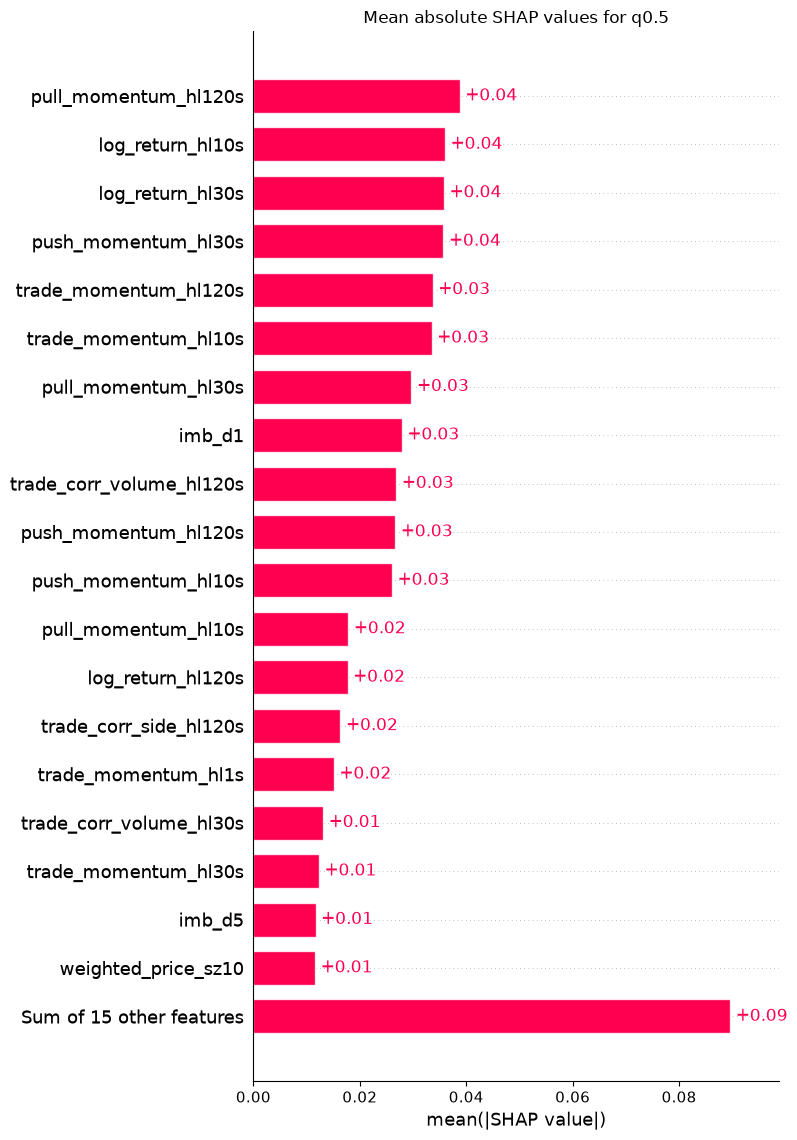

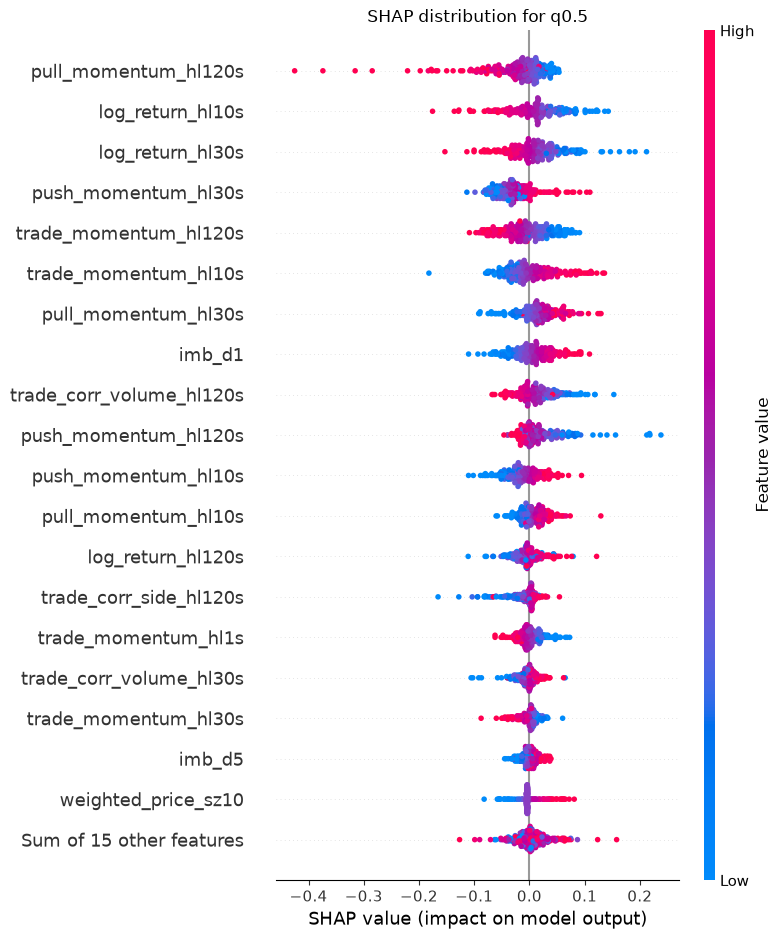

In [6]:
import matplotlib.pyplot as plt


explained_quantile = quantiles[output_index]
shap_explanation = shap.Explanation(
    values=shap_values[:, :, output_index],
    base_values=np.full(
        explain_rows.shape[0],
        expected_values[output_index],
    ),
    data=explain_rows,
    feature_names=list(pipeline.features),
)

shap.plots.bar(
    shap_explanation,
    max_display=20,
    show=False,
)
plt.title(f"Mean absolute SHAP values for q{explained_quantile:g}")
plt.tight_layout()
plt.show()

shap.plots.beeswarm(
    shap_explanation,
    max_display=20,
    show=False,
)
plt.title(f"SHAP distribution for q{explained_quantile:g}")
plt.tight_layout()
plt.show()


## Saved fit history

This section only reads and plots history stored with the selected run. It does not invoke train, refit, or any private pipeline fitting method.


{'best_epoch': 13,
 'best_iteration': 13,
 'best_num_boost_round': 14,
 'best_score': 0.5974401738650288,
 'fold': None,
 'history': {'train': {'loss': [0.7062922796008013,
    0.6722381873698743,
    0.6680413565919654,
    0.6665628929587807,
    0.6657308501779196,
    0.6647185001667124,
    0.6638357081720906,
    0.6628334778611378,
    0.6626166276590602,
    0.6629384599558276,
    0.6611216528983624,
    0.6617082489532711,
    0.6611751854370408,
    0.6612509179697045,
    0.6608553169136505,
    0.6596104914092938,
    0.6599074825706119,
    0.659130123008668,
    0.6581314755827066,
    0.6589502549250329,
    0.658755088858214,
    0.6585932568245628,
    0.6584866506142297,
    0.6575510147635457]},
  'val': {'loss': [0.6190067164413112,
    0.6095646989627801,
    0.5998003105101147,
    0.6025758340830258,
    0.6035484436245682,
    0.6060945673905376,
    0.6015187671672667,
    0.6071997406921015,
    0.6051593786079571,
    0.6006346853828696,
    0.59963123155835

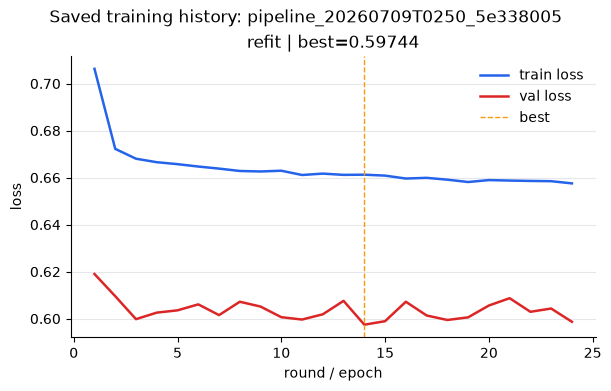

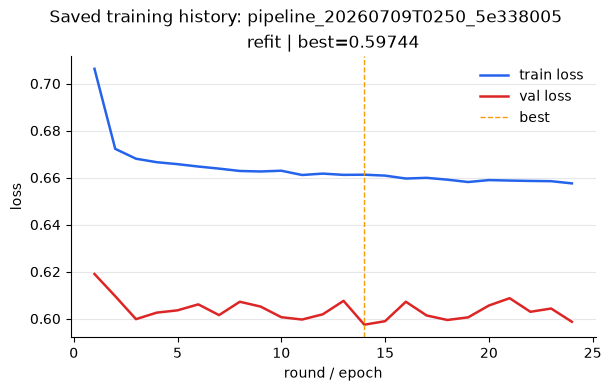

In [7]:
from tools.pipeline import plot_train_val_loss


saved_refit_history = selected_history.get("refit_history")
display(saved_refit_history)

plot_train_val_loss(
    saved_refit_history or selected_history,
    title=f"Saved training history: {selected_run_dir.name}",
)
